# Análisis Exploratorio de Datos (EDA)
## Dataset: Créditos Financieros
**Objetivo:** Analizar la base de datos de créditos para identificar patrones,
distribuciones, calidad de datos y relaciones con la variable objetivo `Pago_atiempo`.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

In [4]:
import sys, os

sys.path.insert(0, os.getcwd())

from cargar_datos import CargarDatos

df = CargarDatos()
df.head()

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,695.0,10,5,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,789.0,3,1,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,740.0,4,5,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,837.0,4,4,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,771.0,4,6,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


## 1. Exploración Inicial de los Datos

In [5]:
print("Dimensiones del dataset:", df.shape)
print("Tipos de datos:")
print(df.dtypes)

Dimensiones del dataset: (10763, 23)
Tipos de datos:
tipo_credito                              int64
fecha_prestamo                   datetime64[ns]
capital_prestado                        float64
plazo_meses                               int64
edad_cliente                              int64
tipo_laboral                             object
salario_cliente                           int64
total_otros_prestamos                     int64
cuota_pactada                             int64
puntaje                                 float64
puntaje_datacredito                     float64
cant_creditosvigentes                     int64
huella_consulta                           int64
saldo_mora                              float64
saldo_total                             float64
saldo_principal                         float64
saldo_mora_codeudor                     float64
creditos_sectorFinanciero                 int64
creditos_sectorCooperativo                int64
creditos_sectorReal                

In [6]:
df.head()

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,695.0,10,5,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,789.0,3,1,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,740.0,4,5,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,837.0,4,4,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,771.0,4,6,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


In [7]:
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({'Nulos': nulos, 'Nulos': pct_nulos})
resumen_nulos[resumen_nulos['Nulos'] > 0].sort_values('Nulos', ascending=False)

,Nulos
tendencia_ingresos,27.24
promedio_ingresos_datacredito,27.22
saldo_mora_codeudor,5.48
saldo_principal,3.76
saldo_mora,1.45
saldo_total,1.45
puntaje_datacredito,0.06


## 2. Identificación y Clasificación de Variables

In [9]:
variables_numericas = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
variables_categoricas = df.select_dtypes(include=['object']).columns.tolist()

print("Variables numéricas:", variables_numericas)
print("Variables categóricas:", variables_categoricas)

Variables numéricas: ['tipo_credito', 'capital_prestado', 'plazo_meses', 'edad_cliente', 'salario_cliente', 'total_otros_prestamos', 'cuota_pactada', 'puntaje', 'puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta', 'saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor', 'creditos_sectorFinanciero', 'creditos_sectorCooperativo', 'creditos_sectorReal', 'promedio_ingresos_datacredito', 'Pago_atiempo']
Variables categóricas: ['tipo_laboral', 'tendencia_ingresos']


In [10]:
# fecha_prestamo como datetime
df['fecha_prestamo'] = pd.to_datetime(df['fecha_prestamo'])

# tipo_credito como categoría (es código, no número)
df['tipo_credito'] = df['tipo_credito'].astype('category')

# Revisar valores inconsistentes en tendencia_ingresos
print(df['tendencia_ingresos'].value_counts(dropna=False))

tendencia_ingresos
Creciente      5294
NaN            2932
Decreciente    1291
Estable        1188
0                 7
8315              6
1000000           4
9147              2
158042            1
168750            1
3978              1
-28589            1
-566272           1
24702             1
31837             1
122727            1
417087            1
9090              1
173031            1
-70715            1
-435177           1
-702927           1
-4105             1
54683             1
22832             1
209090            1
5697              1
10808             1
-288              1
-164315           1
2029000           1
17181             1
15245             1
82657             1
52862             1
1817052           1
75761             1
146918            1
1123000           1
15090             1
4250635           1
22363             1
-101368           1
86286             1
65988             1
77975             1
-224714           1
Name: count, dtype: int64


## 3. Estadísticas Descriptivas

In [14]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
fecha_prestamo,10763,2025-04-16 23:06:02.111121664,2024-11-26 09:17:04,2025-01-20 17:33:07.500000,2025-03-27 16:23:12,2025-06-16 13:27:58,2026-04-26 18:43:52,NaN
capital_prestado,10763.0,2434315.001319,360000.0,1224831.0,1921920.0,3084840.0,41444152.8,1909642.758997
plazo_meses,10763.0,10.575583,2.0,6.0,10.0,12.0,90.0,6.632082
edad_cliente,10763.0,43.94862,19.0,33.0,42.0,53.0,123.0,15.060877
salario_cliente,10763.0,17216431.459909,0.0,2000000.0,3000000.0,4875808.0,22000000000.0,355476717.603482
total_otros_prestamos,10763.0,6238869.648518,0.0,500000.0,1000000.0,2000000.0,6787675263.0,118418316.941069
cuota_pactada,10763.0,243617.406671,23944.0,121041.5,182863.0,287833.5,3816752.0,210493.694608
puntaje,10763.0,91.170036,-38.00999,95.227787,95.227787,95.227787,95.227787,16.465441
puntaje_datacredito,10757.0,780.790834,-7.0,757.0,791.0,825.0,999.0,104.878031
cant_creditosvigentes,10763.0,5.726749,0.0,3.0,5.0,8.0,62.0,3.977162


## 4. Análisis Univariado
### 4.1 Variables Numéricas

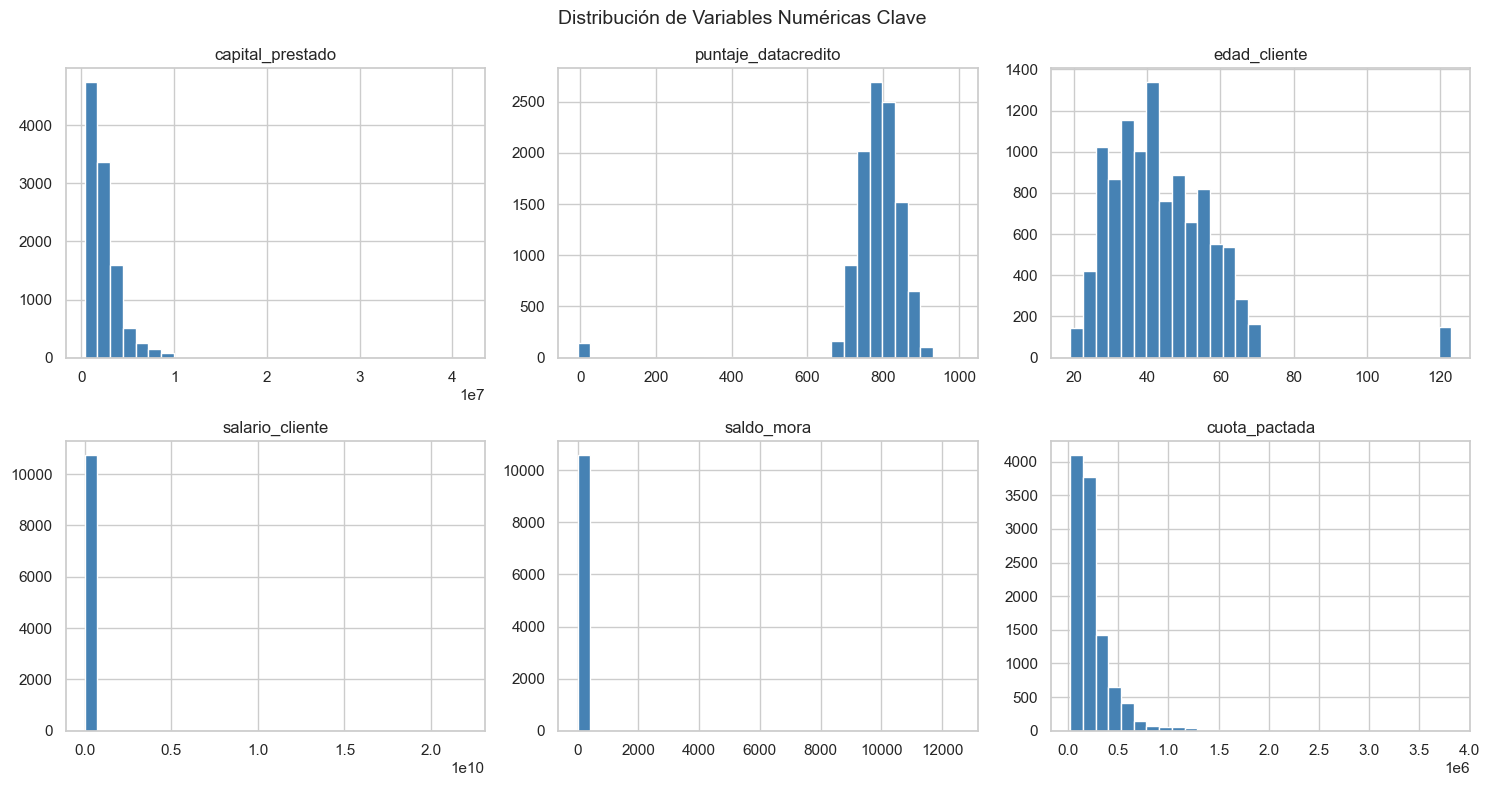

In [15]:
cols_clave = ['capital_prestado', 'puntaje_datacredito', 'edad_cliente',
              'salario_cliente', 'saldo_mora', 'cuota_pactada']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cols_clave):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.suptitle('Distribución de Variables Numéricas Clave', fontsize=14)
plt.tight_layout()
plt.savefig('histogramas_numericas.png', dpi=150)
plt.show()

### 4.2 Variables Categóricas

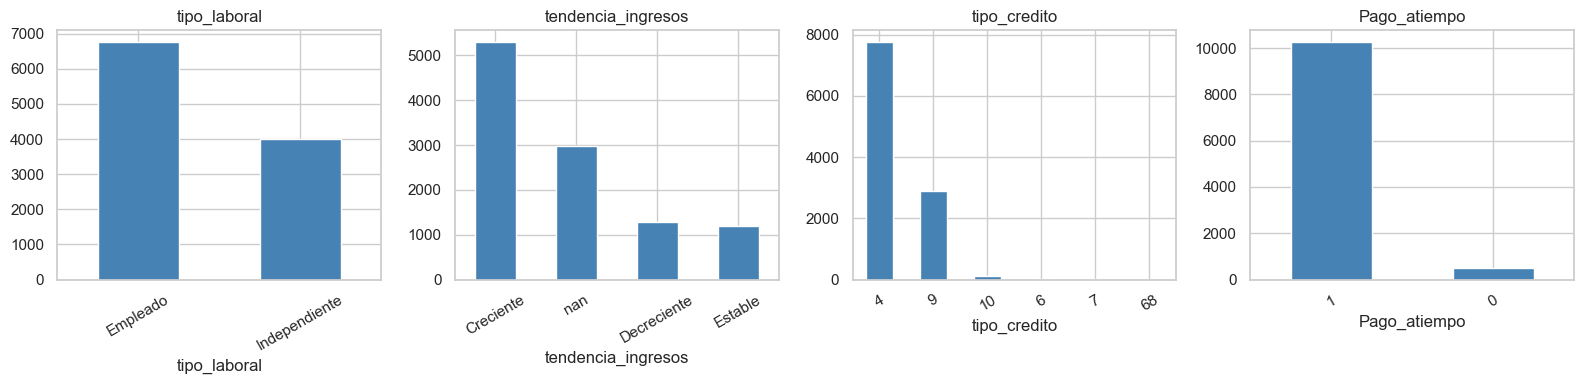

In [16]:
cols_cat = ['tipo_laboral', 'tendencia_ingresos', 'tipo_credito', 'Pago_atiempo']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(cols_cat):
    df[col].value_counts(dropna=False).plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('barplots_categoricas.png', dpi=150)
plt.show()

## 5. Análisis Bivariado
### 5.1 Variables numéricas vs Pago_atiempo

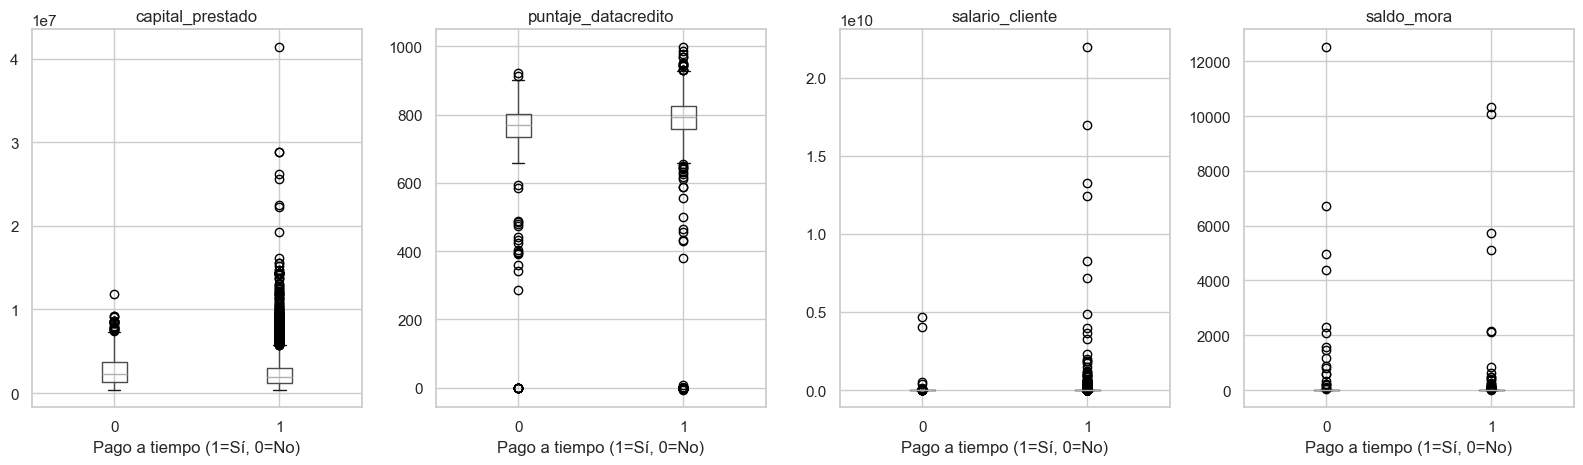

In [18]:
cols_bivariado = ['capital_prestado', 'puntaje_datacredito', 'salario_cliente', 'saldo_mora']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for i, col in enumerate(cols_bivariado):
    df.boxplot(column=col, by='Pago_atiempo', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('Pago a tiempo (1=Sí, 0=No)')

plt.suptitle('')
plt.tight_layout()
plt.savefig('boxplots_vs_target.png', dpi=150)
plt.show()

### 5.3 Matriz de correlación

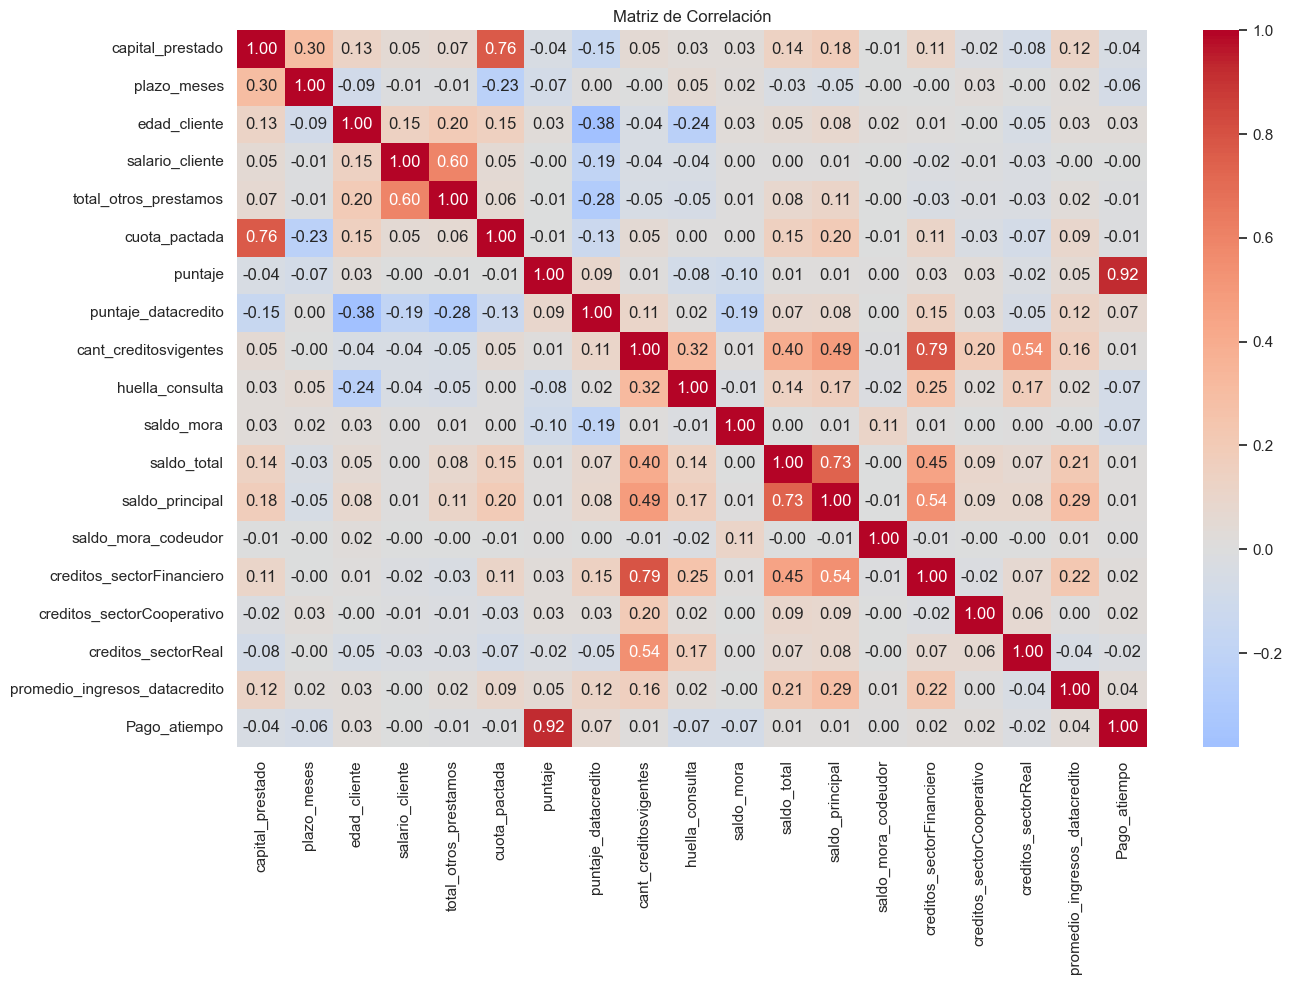

In [23]:
cols_corr = df.select_dtypes(include=['float64', 'int64']).columns.to_list()

plt.figure(figsize=(14, 10))
sns.heatmap(df[cols_corr].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.savefig('heatmap_correlacion.png', dpi=150)
plt.show()

## Alerta: posible data leakage en variable `puntaje`
La correlación de 0.92 con `Pago_atiempo` es inusualmente alta para datos crudos.
Se recomienda verificar con el equipo/fuente si `puntaje` es calculado
con información posterior al evento de pago. De confirmarse, esta variable
debe ser excluida del modelo para evitar fuga de información.

JUAN PABLO PENA G
